In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
nodes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Nodes')
pipes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Pipelines')

months = [str(m).zfill(2) + '-2024' for m in range(1, 13)]

res_total = pd.concat(
    [pd.read_excel('./input/Gas Cons Distrib.xlsx', sheet_name=m)['Physical Flow (MNm3)']
     for m in months], ignore_index=True
).values.astype(np.float32)

ind_total = pd.concat(
    [pd.read_excel('./input/Gas Cons Ind.xlsx', sheet_name=m)['Physical Flow (MNm3)']
     for m in months], ignore_index=True
).values.astype(np.float32)

# exp retiré (corr=-0.007)

q_full = pd.concat(
    [pd.read_excel('./output/Decision_variablesRU.xlsx',
                   sheet_name=f'q-{m}').iloc[:, 1:] for m in months],
    ignore_index=True
).values.astype(np.float32)   # [8784, 33]

g_full = pd.concat(
    [pd.read_excel('./output/Decision_variablesRU.xlsx',
                   sheet_name=f'g-{m}')[[0, 1, 2, 3]] for m in months],
    ignore_index=True
).values.astype(np.float32)   # [8784, 4]

print('q_full:', q_full.shape)
print('g_full:', g_full.shape)

q_full: (8784, 33)
g_full: (8784, 4)


In [3]:
N        = 28
T        = 8784
WELL_IDX = [0, 4, 16, 17]   # nœuds 1,5,17,18 en 0-based

nodes_df  = nodes_df.sort_values('Gas Node').reset_index(drop=True)
res_share = nodes_df['Res_Load_share_%'].values.astype(np.float32)
ind_share = nodes_df['Ind_Load_share_%'].values.astype(np.float32)

# Signal par nœud [T, N] — comme le q_t de l'article :
#   nœuds demande  : consommation pondérée
#   nœuds puits    : injection g  (signal auto-régressif + cible)
X_node = (
    np.outer(res_total, res_share) +
    np.outer(ind_total, ind_share)
).astype(np.float32)
X_node[:, WELL_IDX] = g_full   # override wells avec g

# Matrice d'adjacence W (paper eq.10) :
#   w_ij = longueur (km) pour pipes passifs
#   w_ij = 0.01          pour éléments actifs (compresseurs, NaN longueur)
pipes_df = pipes_df[['Pipeline', 'From node', 'To node',
                      'Compressor factor', 'Estimated lenght [km]']].copy()

W_adj = np.zeros((N, N), dtype=np.float32)
for _, row in pipes_df.iterrows():
    u = int(row['From node']) - 1
    v = int(row['To node'])   - 1
    L = row['Estimated lenght [km]']
    w = 0.01 if (pd.isna(L) or float(L) == 0.0) else float(L)
    W_adj[u, v] = w
    W_adj[v, u] = w

print('X_node :', X_node.shape)
print('Pipes passifs :', ((W_adj > 0.01)).sum() // 2)
print('Éléments actifs (0.01) :', (W_adj == 0.01).sum() // 2)

X_node : (8784, 28)
Pipes passifs : 29
Éléments actifs (0.01) : 4


In [4]:
# Suit exactement la section 3.1 de l'article (Defferrard et al.)
# L = I - D^{-1/2} W D^{-1/2}
# L_tilde = 2L / lambda_max - I
# T_0 = I,  T_1 = L_tilde,  T_k = 2*L_tilde*T_{k-1} - T_{k-2}

K_CHEB = 3   # ordre Chebyshev (paper: Ks=3)

def compute_cheb_stack(W_adj, K, device):
    N = W_adj.shape[0]
    D = W_adj.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(D, 1e-10)))
    L = np.eye(N, dtype=np.float32) - D_inv_sqrt @ W_adj @ D_inv_sqrt
    lam_max = float(np.linalg.eigvalsh(L).max())
    L_tilde  = (2.0 / lam_max) * L - np.eye(N, dtype=np.float32)

    L_t = torch.tensor(L_tilde, dtype=torch.float32, device=device)
    I_n = torch.eye(N, dtype=torch.float32, device=device)

    polys = [I_n, L_t]
    for k in range(2, K):
        polys.append(2.0 * L_t @ polys[-1] - polys[-2])

    return torch.stack(polys[:K], dim=0)   # [K, N, N]

cheb_stack = compute_cheb_stack(W_adj, K_CHEB, device)
print('cheb_stack :', cheb_stack.shape)   # [3, 28, 28]

cheb_stack : torch.Size([3, 28, 28])


In [5]:
W_IN  = 72
W_OUT = 24
BLOCK = W_IN + W_OUT

# Features temporelles cycliques (exogènes, paper section 3)
hours    = np.arange(T)
hour_sin = np.sin(2*np.pi*(hours % 24)      / 24).astype(np.float32)
hour_cos = np.cos(2*np.pi*(hours % 24)      / 24).astype(np.float32)
dow_sin  = np.sin(2*np.pi*(hours // 24 % 7) / 7 ).astype(np.float32)
dow_cos  = np.cos(2*np.pi*(hours // 24 % 7) / 7 ).astype(np.float32)

ex_feats = np.stack([
    np.tile(hour_sin[:, None], (1, N)),
    np.tile(hour_cos[:, None], (1, N)),
    np.tile(dow_sin[:,  None], (1, N)),
    np.tile(dow_cos[:,  None], (1, N)),
], axis=-1).astype(np.float32)   # [T, N, 4]

# Normalisation du signal nœud (Z-score comme dans l'article)
x_scaler    = StandardScaler().fit(X_node)
X_node_norm = x_scaler.transform(X_node).astype(np.float32)

# Stack final : [T, N, 5]  = flow(1) + exo(4)
X_full = np.concatenate([X_node_norm[:, :, None], ex_feats], axis=-1)

y_scaler = StandardScaler().fit(g_full)
Y_norm   = y_scaler.transform(g_full).astype(np.float32)

# Fenêtrage glissant step=6 (paper: sliding window Figure 6)
starts  = np.arange(0, T - BLOCK + 1, 6)
X_win   = np.stack([X_full[s : s + W_IN]         for s in starts])   # [S, 72, N, 5]
Y_win   = np.stack([Y_norm[s + W_IN : s + BLOCK] for s in starts])   # [S, 24, 4]

S       = len(starts)
s_train = int(0.70 * S)
s_val   = int(0.85 * S)

X_train, Y_train = X_win[:s_train],      Y_win[:s_train]
X_val,   Y_val   = X_win[s_train:s_val], Y_win[s_train:s_val]
X_test,  Y_test  = X_win[s_val:],        Y_win[s_val:]

print(f'X_win : {X_win.shape}   Y_win : {Y_win.shape}')
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

X_win : (1449, 72, 28, 5)   Y_win : (1449, 24, 4)
Train: 1014 | Val: 217 | Test: 218


In [6]:
class GasDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

BATCH = 32   # paper: batch_size=32

train_loader = DataLoader(GasDataset(X_train, Y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(GasDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(GasDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False)
print(f'Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

Batches — train:32  val:7  test:7


In [18]:
# ── CELL 7 — Modèle DLST ─────────────────────────────────────────────────────
C1    = 16
CS1   = 32
CT    = 32
CS2   = 32
KT    = 3
LDROP = 0.2


class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation=1):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=0)

    def forward(self, x):
        return self.conv(F.pad(x, (self.pad, 0)))


class SGCU(nn.Module):
    def __init__(self, in_ch, out_ch, K):
        super().__init__()
        self.out_ch = out_ch
        self.theta  = nn.Parameter(torch.empty(K, in_ch, out_ch))
        with torch.no_grad():
            for k in range(K):
                nn.init.xavier_uniform_(self.theta[k])
        self.norm = nn.LayerNorm(out_ch)

    def forward(self, x, cheb_stack):
        # x          : [B, T, N, in_ch]
        # cheb_stack : [K, N, N]
        B, T, N, C = x.shape
        x_r  = x.reshape(B * T, N, C)
        Tx   = torch.einsum('knm,bmc->kbnc', cheb_stack, x_r)   # [K, B*T, N, C]
        out  = torch.einsum('kbnc,kco->bno', Tx, self.theta)    # [B*T, N, out_ch]
        return F.relu(self.norm(out)).reshape(B, T, N, self.out_ch)


class TCULayer(nn.Module):
    def __init__(self, channels, kernel, dilation, dropout=0.2):
        super().__init__()
        self.causal = CausalConv1d(channels, channels, kernel, dilation)
        self.drop   = nn.Dropout(dropout)

    def forward(self, x):
        # x : [B*N, C, T]
        return x + self.drop(F.relu(self.causal(x)))


class TCU(nn.Module):
    def __init__(self, channels, kernel, n_layers=4, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList([
            TCULayer(channels, kernel, dilation=2**l, dropout=dropout)
            for l in range(n_layers)
        ])

    def forward(self, x):
        # x : [B, T, N, C]
        B, T, N, C = x.shape
        h = x.permute(0, 2, 3, 1).reshape(B * N, C, T)
        for layer in self.layers:
            h = layer(h)
        return h.reshape(B, N, C, T).permute(0, 3, 1, 2)


class DLST(nn.Module):
    def __init__(self, in_q=1, in_ex=4, c1=32, cs1=64, ct=64, cs2=64,
                 kt=3, K=3, l_tcu=4, w_out=24, dropout=0.2):
        super().__init__()

        self.conv_q = nn.Sequential(
            CausalConv1d(in_q, c1, kt), nn.ReLU(), nn.Dropout(dropout)
        )
        self.conv_ex = nn.Sequential(
            CausalConv1d(in_ex, c1, kt), nn.ReLU(), nn.Dropout(dropout)
        )

        self.sgcu1     = SGCU(2 * c1, cs1, K)
        self.proj      = nn.Linear(cs1, ct) if cs1 != ct else nn.Identity()
        self.tcu       = TCU(ct, kt, l_tcu, dropout)
        self.sgcu2     = SGCU(ct, cs2, K)
        self.final_conv = nn.Sequential(
            CausalConv1d(cs2, cs2, kt), nn.ReLU()
        )
        self.fc        = nn.Linear(cs2, w_out)
        self.well_idx  = WELL_IDX
        self.w_out     = w_out

    def forward(self, x, cheb_stack):
        # x : [B, W_IN, N, 5]
        B, W, N, F = x.shape

        x_q  = x[:, :, :, :1]   # [B, W, N, 1]
        x_ex = x[:, :, :, 1:]   # [B, W, N, 4]

        q_r  = x_q.permute(0, 2, 3, 1).reshape(B * N, 1, W)
        ex_r = x_ex.permute(0, 2, 3, 1).reshape(B * N, 4, W)

        q_out  = self.conv_q(q_r)    # [B*N, C1, W]
        ex_out = self.conv_ex(ex_r)  # [B*N, C1, W]
        C1_out = q_out.shape[1]

        q_out  = q_out.reshape(B, N, C1_out, W).permute(0, 3, 1, 2)
        ex_out = ex_out.reshape(B, N, C1_out, W).permute(0, 3, 1, 2)
        h = torch.cat([q_out, ex_out], dim=-1)   # [B, W, N, 2*C1]

        h = self.sgcu1(h, cheb_stack)   # [B, W, N, CS1]
        h = self.proj(h)                # [B, W, N, CT]
        h = self.tcu(h)                 # [B, W, N, CT]
        h = self.sgcu2(h, cheb_stack)   # [B, W, N, CS2]

        h_r = h.permute(0, 2, 3, 1).reshape(B * N, -1, W)
        h_r = self.final_conv(h_r)
        h   = h_r.reshape(B, N, -1, W).permute(0, 3, 1, 2)   # [B, W, N, CS2]

        h_last = h[:, -1, self.well_idx, :]   # [B, 4, CS2]
        out    = self.fc(h_last)               # [B, 4, W_OUT]
        return out.permute(0, 2, 1)            # [B, W_OUT, 4]


model = DLST(in_q=1, in_ex=4, c1=C1, cs1=CS1, ct=CT, cs2=CS2,
             kt=KT, K=K_CHEB, l_tcu=4, w_out=W_OUT, dropout=LDROP).to(device)

print(f'Paramètres : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(type(model))

Paramètres : 22,856
<class '__main__.DLST'>


In [19]:
# Paper section 5 :
#   Adam, LR=0.001, decay 0.9 every 5 epochs, 50 epochs, batch=32

EPOCHS   = 100    # on laisse plus de marge que le paper (50)
LR       = 5e-4
PATIENCE = 30

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.MSELoss()

# LR decay ×0.9 toutes les 5 epochs (paper)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

best_val  = float('inf')
patience_cnt = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb, cheb_stack), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(xb)
    train_loss = total / len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        total = sum(
            criterion(model(xb.to(device), cheb_stack), yb.to(device)).item() * len(xb)
            for xb, yb in val_loader
        )
    val_loss = total / len(val_loader.dataset)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 2 == 0:
        print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}'
              f'  lr={optimizer.param_groups[0]["lr"]:.2e}')

    if val_loss < best_val:
        best_val     = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), 'best_dlst.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stop epoch {epoch}')
            break

plt.figure(figsize=(10, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE normalisé')
plt.legend(); plt.tight_layout(); plt.show()

Epoch   2 | train=0.8766  val=0.6722  lr=5.00e-04


KeyboardInterrupt: 

C:\Users\yoans\AppData\Local\Temp\ipykernel_23528\3680361537.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_dlst.pt'))


Puits            MAE      RMSE      NMAE
--------------------------------------------
Node 1        0.3313    0.4249    14.53%
Node 5        0.2907    0.3680    41.36%
Node 17       0.2178    0.2714    15.48%
Node 18       0.2000    0.2489    40.71%

Total         0.6015    0.7847    12.32%


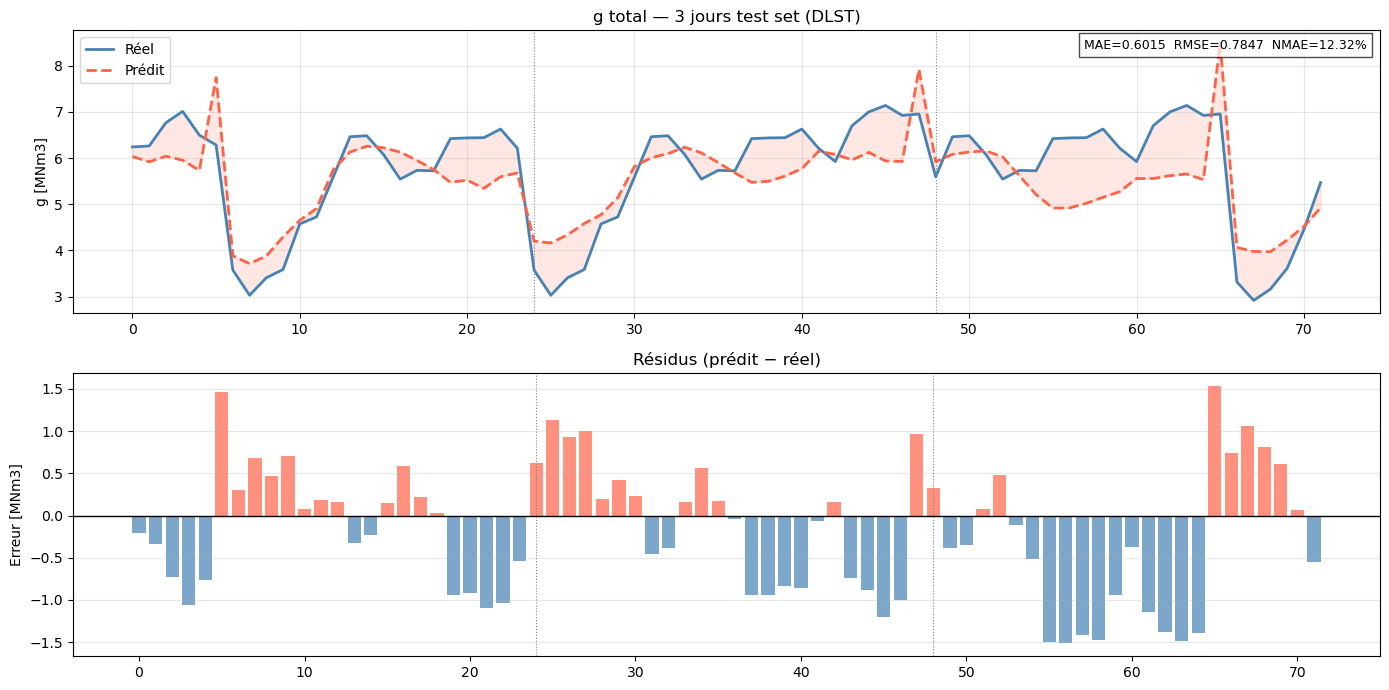

In [17]:
model.load_state_dict(torch.load('best_dlst.pt'))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(model(xb.to(device), cheb_stack).cpu().numpy())
        trues.append(yb.numpy())

preds = np.concatenate(preds)   # [S_test, 24, 4]
trues = np.concatenate(trues)
S_test = len(preds)

preds_real = y_scaler.inverse_transform(preds.reshape(-1, 4)).reshape(S_test, 24, 4)
trues_real = y_scaler.inverse_transform(trues.reshape(-1, 4)).reshape(S_test, 24, 4)

trues_train_real = y_scaler.inverse_transform(Y_train.reshape(-1, 4)).reshape(-1, 24, 4)

well_names = ['Node 1', 'Node 5', 'Node 17', 'Node 18']
print(f"{'Puits':<10}  {'MAE':>8}  {'RMSE':>8}  {'NMAE':>8}")
print('-' * 44)
for i, name in enumerate(well_names):
    mae  = np.mean(np.abs(preds_real[:,:,i] - trues_real[:,:,i]))
    rmse = np.sqrt(np.mean((preds_real[:,:,i] - trues_real[:,:,i])**2))
    ref  = np.mean(np.abs(trues_train_real[:,:,i]))
    nmae = mae / ref * 100
    print(f'{name:<10}  {mae:>8.4f}  {rmse:>8.4f}  {nmae:>7.2f}%')

total_pred = preds_real.sum(axis=2)
total_true = trues_real.sum(axis=2)
total_train = trues_train_real.sum(axis=2)
mae_tot  = np.mean(np.abs(total_pred - total_true))
rmse_tot = np.sqrt(np.mean((total_pred - total_true)**2))
nmae_tot = mae_tot / np.mean(np.abs(total_train)) * 100
print(f'\n{"Total":<10}  {mae_tot:>8.4f}  {rmse_tot:>8.4f}  {nmae_tot:>7.2f}%')

# Visualisation 3 jours
N_DAYS = 3
total_true_cont = np.concatenate([total_true[d] for d in range(N_DAYS)])
total_pred_cont = np.concatenate([total_pred[d] for d in range(N_DAYS)])
t = np.arange(N_DAYS * 24)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(t, total_true_cont, label='Réel',   lw=2, color='steelblue')
axes[0].plot(t, total_pred_cont, label='Prédit', lw=2, color='tomato', ls='--')
axes[0].fill_between(t, total_true_cont, total_pred_cont, alpha=0.15, color='tomato')
for d in range(1, N_DAYS):
    axes[0].axvline(d*24, color='grey', lw=0.8, ls=':')
axes[0].set_title('g total — 3 jours test set (DLST)')
axes[0].set_ylabel('g [MNm3]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.99, 0.97, f'MAE={mae_tot:.4f}  RMSE={rmse_tot:.4f}  NMAE={nmae_tot:.2f}%',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7))

res = total_pred_cont - total_true_cont
axes[1].bar(t, res, color=['tomato' if r > 0 else 'steelblue' for r in res], alpha=0.7)
axes[1].axhline(0, color='black', lw=1)
for d in range(1, N_DAYS):
    axes[1].axvline(d*24, color='grey', lw=0.8, ls=':')
axes[1].set_title('Résidus (prédit − réel)')
axes[1].set_ylabel('Erreur [MNm3]'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()